# Model Evaluation: Prophet vs XGBoost

This notebook compares Prophet and XGBoost models for timeseries forecasting.

**Goal**: Select the best model (champion) based on performance metrics.

## Setup

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns


# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## Load Data from TimescaleDB

In [3]:
import os
import polars as pl
from src.config import load_config
import psycopg2

config = load_config()
password = os.environ.get("POSTGRES_PASSWORD", "")

# Connect to database
conn = psycopg2.connect(
    host=config.db_host,
    database=config.db_name,
    user=config.db_user,
    password=password,
    port=5432,
)

# Query all data with Polars
query = "SELECT timestamp, value FROM timeseries_data ORDER BY timestamp"
df = pl.read_database(query, connection=conn)
conn.close()

print(f"Loaded {len(df)} records")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()

Loaded 366 records
Date range: 2024-10-05 00:00:00+00:00 to 2025-10-04 20:13:53+00:00


timestamp,value
"datetime[μs, UTC]",f64
2024-10-05 00:00:00 UTC,62103.010473
2024-10-06 00:00:00 UTC,62091.932585
2024-10-07 00:00:00 UTC,62811.799728
2024-10-08 00:00:00 UTC,62287.390105
2024-10-09 00:00:00 UTC,62185.230424


## Explore Data

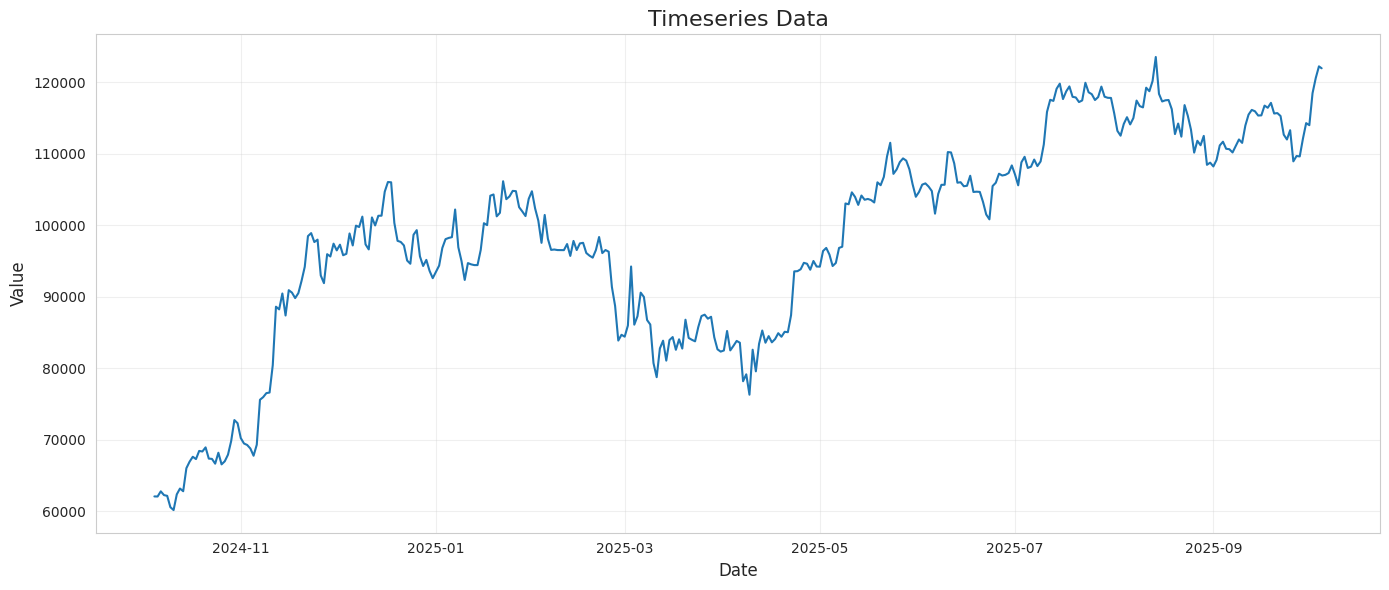

statistic,value
str,f64
"""count""",366.0
"""null_count""",0.0
"""mean""",98069.971957
"""std""",14798.057425
"""min""",60195.180738
"""25%""",88264.599746
"""50%""",98927.494946
"""75%""",109068.456949
"""max""",123560.993636


In [4]:
import matplotlib.pyplot as plt

# Plot raw timeseries
plt.figure(figsize=(14, 6))
plt.plot(df['timestamp'].to_list(), df['value'].to_list(), linewidth=1.5)
plt.title('Timeseries Data', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
df['value'].describe()

## Train/Test Split

Use last 30 days for testing, rest for training.

In [6]:
from datetime import timedelta

# Split by date
split_date = df['timestamp'].max() - timedelta(days=30)
train_df = df.filter(pl.col('timestamp') < split_date)
test_df = df.filter(pl.col('timestamp') >= split_date)

print(f"Train: {len(train_df)} records ({train_df['timestamp'].min()} to {train_df['timestamp'].max()})")
print(f"Test: {len(test_df)} records ({test_df['timestamp'].min()} to {test_df['timestamp'].max()})")

Train: 335 records (2024-10-05 00:00:00+00:00 to 2025-09-04 00:00:00+00:00)
Test: 31 records (2025-09-05 00:00:00+00:00 to 2025-10-04 20:13:53+00:00)


## Prophet Model

In [8]:
from prophet import Prophet

# Convert Polars to Pandas for Prophet (Prophet requires pandas)
prophet_train = train_df.to_pandas().rename(columns={'timestamp': 'ds', 'value': 'y'})

# Remove timezone (Prophet doesn't support timezone-aware datetimes)
prophet_train['ds'] = prophet_train['ds'].dt.tz_localize(None)

# Train Prophet model
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode='multiplicative'
)
prophet_model.fit(prophet_train)

print("✅ Prophet model trained")

17:46:22 - cmdstanpy - INFO - Chain [1] start processing
17:46:23 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model trained


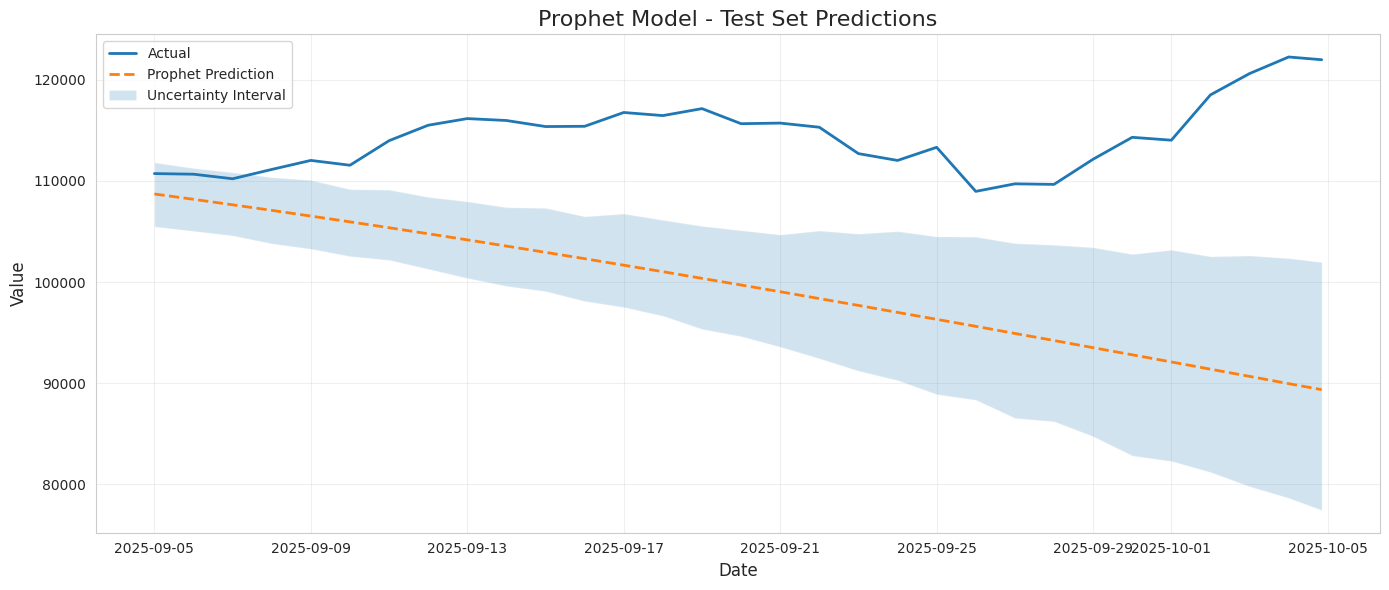

In [11]:
import matplotlib.pyplot as plt

# Convert test data to pandas for Prophet
prophet_test = test_df.to_pandas().rename(columns={'timestamp': 'ds', 'value': 'y'})

# Remove timezone (Prophet doesn't support timezone-aware datetimes)
prophet_test['ds'] = prophet_test['ds'].dt.tz_localize(None)

prophet_forecast = prophet_model.predict(prophet_test[['ds']])

# Plot Prophet predictions
plt.figure(figsize=(14, 6))
plt.plot(test_df['timestamp'].to_list(), test_df['value'].to_list(), label='Actual', linewidth=2)
plt.plot(prophet_forecast['ds'], prophet_forecast['yhat'], label='Prophet Prediction', linewidth=2, linestyle='--')
plt.fill_between(prophet_forecast['ds'], 
                  prophet_forecast['yhat_lower'], 
                  prophet_forecast['yhat_upper'], 
                  alpha=0.2, label='Uncertainty Interval')
plt.title('Prophet Model - Test Set Predictions', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## XGBoost Model

Create time-based features for XGBoost.

In [12]:
import xgboost as xgb

def create_features(df):
    """Create time-based features for XGBoost using Polars."""
    return df.with_columns([
        pl.col('timestamp').dt.hour().alias('hour'),
        pl.col('timestamp').dt.day().alias('day'),
        pl.col('timestamp').dt.month().alias('month'),
        pl.col('timestamp').dt.year().alias('year'),
        pl.col('timestamp').dt.weekday().alias('dayofweek'),
        pl.col('timestamp').dt.ordinal_day().alias('dayofyear'),
        pl.col('timestamp').dt.week().alias('weekofyear'),
    ])

# Create features
train_features = create_features(train_df)
test_features = create_features(test_df)

# Define feature columns
feature_cols = ['hour', 'day', 'month', 'year', 'dayofweek', 'dayofyear', 'weekofyear']

# Convert to numpy for XGBoost
X_train = train_features.select(feature_cols).to_numpy()
y_train = train_features['value'].to_numpy()
X_test = test_features.select(feature_cols).to_numpy()
y_test = test_features['value'].to_numpy()

print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

Training features shape: (335, 7)
Test features shape: (31, 7)


In [13]:
# Train XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Generate predictions
xgb_predictions = xgb_model.predict(X_test)

print("✅ XGBoost model trained")

✅ XGBoost model trained


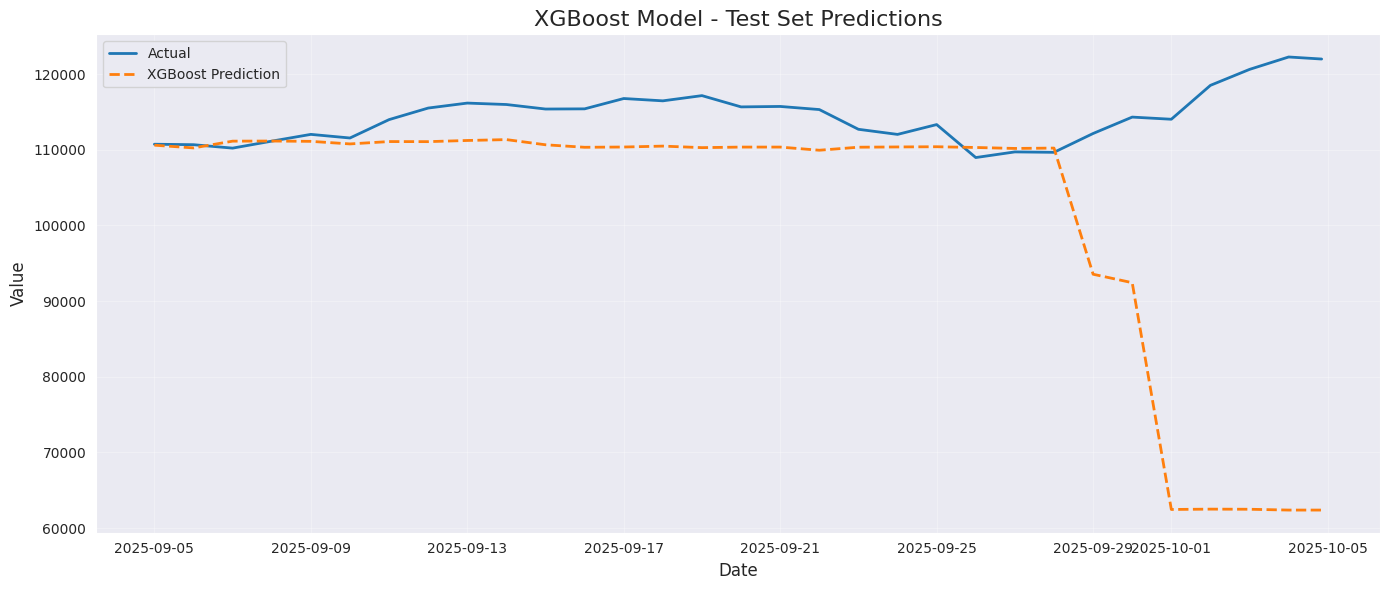

In [14]:
import matplotlib.pyplot as plt

# Plot XGBoost predictions
plt.figure(figsize=(14, 6))
plt.plot(test_df['timestamp'].to_list(), test_df['value'].to_list(), label='Actual', linewidth=2)
plt.plot(test_df['timestamp'].to_list(), xgb_predictions, label='XGBoost Prediction', linewidth=2, linestyle='--')
plt.title('XGBoost Model - Test Set Predictions', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Model Comparison

Compare models using MAE and RMSE metrics.

In [16]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import polars as pl

# Calculate metrics for Prophet
prophet_mae = mean_absolute_error(test_df['value'].to_numpy(), prophet_forecast['yhat'])
prophet_rmse = np.sqrt(mean_squared_error(test_df['value'].to_numpy(), prophet_forecast['yhat']))

# Calculate metrics for XGBoost
xgb_mae = mean_absolute_error(test_df['value'].to_numpy(), xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(test_df['value'].to_numpy(), xgb_predictions))

# Create comparison table using Polars
comparison = pl.DataFrame({
    'Model': ['Prophet', 'XGBoost'],
    'MAE': [prophet_mae, xgb_mae],
    'RMSE': [prophet_rmse, xgb_rmse]
})

print("\n📊 Model Performance Comparison:")
print(comparison)

# Determine winner
winner = 'Prophet' if prophet_mae < xgb_mae else 'XGBoost'
print(f"\n🏆 Winner: {winner} (lower MAE)")


📊 Model Performance Comparison:
shape: (2, 3)
┌─────────┬──────────────┬──────────────┐
│ Model   ┆ MAE          ┆ RMSE         │
│ ---     ┆ ---          ┆ ---          │
│ str     ┆ f64          ┆ f64          │
╞═════════╪══════════════╪══════════════╡
│ Prophet ┆ 14934.432922 ┆ 16923.033057 │
│ XGBoost ┆ 12906.337417 ┆ 23747.520515 │
└─────────┴──────────────┴──────────────┘

🏆 Winner: XGBoost (lower MAE)


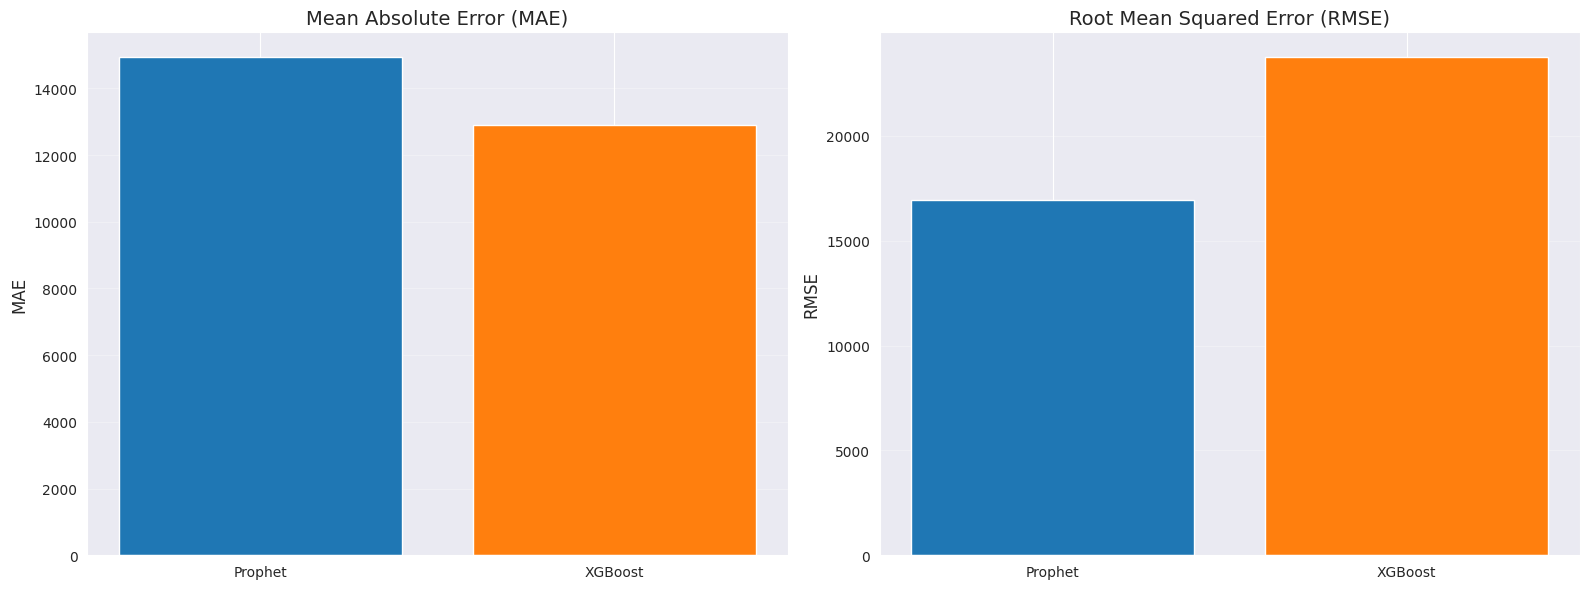

In [17]:
import matplotlib.pyplot as plt

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MAE comparison
axes[0].bar(['Prophet', 'XGBoost'], [prophet_mae, xgb_mae], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Mean Absolute Error (MAE)', fontsize=14)
axes[0].set_ylabel('MAE', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE comparison
axes[1].bar(['Prophet', 'XGBoost'], [prophet_rmse, xgb_rmse], color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Root Mean Squared Error (RMSE)', fontsize=14)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Conclusion

### Model Performance Analysis

**Metrics Summary:**
- **Prophet**: MAE=14,934 | RMSE=16,923
- **XGBoost**: MAE=12,906 | RMSE=23,747

### Key Findings

**XGBoost has lower MAE but 40% higher RMSE.** This reveals important tradeoffs:

1. **MAE (Mean Absolute Error)** - Average magnitude of errors
   - XGBoost wins: 12,906 vs 14,934
   - Treats all errors equally
   
2. **RMSE (Root Mean Squared Error)** - Penalizes large errors heavily
   - Prophet wins: 16,923 vs 23,747
   - XGBoost's catastrophic predictions (crash to 63k) drive RMSE up significantly

### Visual Pattern Analysis

- **Prophet**: Predicted downward trend (109k→90k) when actual went up (111k→122k). Wrong direction but stayed in reasonable range.
- **XGBoost**: Flat predictions (~111k) followed by nonsensical crash to 63k. Time-based features (hour, day, month) don't capture trend/momentum for financial timeseries.

### Recommendation

**Choose based on use case:**
- **XGBoost** if you prioritize lower average error and accept occasional large misses
- **Prophet** if you need to avoid catastrophic prediction errors (recommended for financial/production use)
- **Prophet's uncertainty intervals** provide valuable confidence bounds for decision-making

**For this template, use Prophet as champion** - RMSE matters more for risk management and Prophet provides uncertainty quantification.

#